Sentimental Analysis - Product Reviews


In [1]:
!pip install requests pandas nltk matplotlib.pyplot

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger',quiet=True)

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


True

Fetch Product API data
1. Fetching the reviews and products, based product id mapping the review data with product name

In [2]:
import requests
import json

base_url = "https://fakestoreapiserver.reactbd.org/api"

reviews = []

def fetch_data(base_url:str,url:str)->list:
    fetch_endpoint = f"{base_url}/{url}"
    try:
        response = requests.get(fetch_endpoint, timeout = 10)
        if(response.status_code != 200):
            raise Exception('API fetch is getting issue',response.json())
        data = response.json()
        if "reviews" in url:
            data = data.get('data', [])
        return data

    except Exception as e:
        return e


all_reviews = fetch_data(base_url,'reviews')
all_product_id = [i.get('productId',[]) for i in all_reviews ]

for i in all_product_id:
    product_url = f"products/{i}"
    products = fetch_data(base_url,product_url)
    for review in all_reviews:
        if review['productId'] == products['_id']:
            updated_review  = {**review,'product' : products.get('title')}
            reviews.append(updated_review)

print(json.dumps(reviews[0],indent=2))



{
  "_id": 1,
  "userId": 1,
  "productId": 1,
  "rating": 5,
  "comment": "Amazing camera! Great for beginners, crystal clear images.",
  "createdAt": "2025-06-01T10:00:00Z",
  "product": "Long sleeve Jacket"
}


Setup the Data in Pandas Dataframe

In [3]:
import pandas as pd

def create_set_dataframe(data:list)->pd.DataFrame:
    rows = []
    for i in data:
        rows.append({
            'Product': i.get('product') or "",
            'Rating': i.get('rating') or "rating",
            "userId": i.get("userId") or "",
            'Review': i.get("comment") or ""
        })
    df = pd.DataFrame(rows)
    return df

create_set_dataframe(reviews)
df = create_set_dataframe(reviews)
df.head()

,Product,Rating,userId,Review
0,Long sleeve Jacket,5,1,"Amazing camera! Great for beginners, crystal c..."
1,Jacket with wollen hat,4,2,"Really nice wallet, but I wish it had more car..."
2,Compact fashion t-shirt,3,3,"Drone works well, but battery life could be be..."
3,Blue jins,5,4,Love this shirt! Perfect fit and vibrant colors.
4,Skirts with full setup,4,5,"Great iPad for the price, but storage is limited."


Regex to clean the data

In [4]:
import re

Pattern={
    "url" : re.compile(r'https?//\S+'),
    "html" : re.compile(r'<[^>]+>'),
    "extra_space": re.compile(r'\s+'),
    "punc" : re.compile(r"[a-zA-Z\s]"),
    "ticker": re.compile(r"\b[A-Z]{2,5}\b"),
    "year": re.compile(r"\b(19|20)\d{2}\b"),
    "proper_noun":re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),
    "chars_bracket": re.compile(r'[!,.]\s'), 
}

def clean_text(text:str)->str:
    text = Pattern['url'].sub(' ',text)
    text = Pattern['html'].sub(' ',text)
    text = Pattern['extra_space'].sub(' ',text)
    text = Pattern['chars_bracket'].sub(' ',text)
    print(text,'final')
    return text.strip().lower()

def proper_noun(text:str)->list:
    return Pattern["proper_noun"].findall(text)

def ticker(text:str)->list:
    return Pattern["ticker"].findall(text)

df['clean_text'] = df['Review'].apply(clean_text)
df["proper_noun"] = df["Review"].apply(proper_noun)
df["ticker"] = df["Review"].apply(ticker)
df.head()

Amazing camera Great for beginners crystal clear images. final
Really nice wallet but I wish it had more card slots. final
Drone works well but battery life could be better. final
Love this shirt Perfect fit and vibrant colors. final
Great iPad for the price but storage is limited. final
Awesome tent easy to set up and very durable. final
Phone is great but way too expensive for the features. final
Nice cream hydrates well but has a strong scent. final
Love my new watch Sleek design and great battery life. final
TV stand is sturdy but assembly was a hassle. final
Good headphones sound quality is impressive. final
Super cute sweater my daughter loves it! final
Picnic table is nice but paint chips easily. final
Grill works well heats up quickly. final
Ear buds are fantastic great noise cancellation. final
Kettle is sleek and boils water fast. final
Headphones are top-notch worth every penny. final
Mascara is okay but clumps a bit. final
Wall art looks great but frames feel cheap. final
Y

,Product,Rating,userId,Review,clean_text,proper_noun,ticker
0,Long sleeve Jacket,5,1,"Amazing camera! Great for beginners, crystal c...",amazing camera great for beginners crystal cle...,[],[]
1,Jacket with wollen hat,4,2,"Really nice wallet, but I wish it had more car...",really nice wallet but i wish it had more card...,[],[]
2,Compact fashion t-shirt,3,3,"Drone works well, but battery life could be be...",drone works well but battery life could be bet...,[],[]
3,Blue jins,5,4,Love this shirt! Perfect fit and vibrant colors.,love this shirt perfect fit and vibrant colors.,[],[]
4,Skirts with full setup,4,5,"Great iPad for the price, but storage is limited.",great ipad for the price but storage is limited.,[],[]


Tokenization, Other Data insights

Total Tokens Count: 109
Top word: [('great', 6), ('nice', 3), ('well', 3), ('works', 2), ('battery', 2), ('life', 2), ('love', 2), ('sleek', 2), ('headphones', 2), ('amazing', 1), ('camera', 1), ('beginners', 1), ('crystal', 1), ('clear', 1), ('images', 1), ('really', 1), ('wallet', 1), ('wish', 1), ('card', 1), ('slots', 1)]


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'great'),
  Text(1, 0, 'nice'),
  Text(2, 0, 'well'),
  Text(3, 0, 'works'),
  Text(4, 0, 'battery'),
  Text(5, 0, 'life'),
  Text(6, 0, 'love'),
  Text(7, 0, 'sleek'),
  Text(8, 0, 'headphones'),
  Text(9, 0, 'amazing'),
  Text(10, 0, 'camera'),
  Text(11, 0, 'beginners'),
  Text(12, 0, 'crystal'),
  Text(13, 0, 'clear'),
  Text(14, 0, 'images'),
  Text(15, 0, 'really'),
  Text(16, 0, 'wallet'),
  Text(17, 0, 'wish'),
  Text(18, 0, 'card'),
  Text(19, 0, 'slots')])

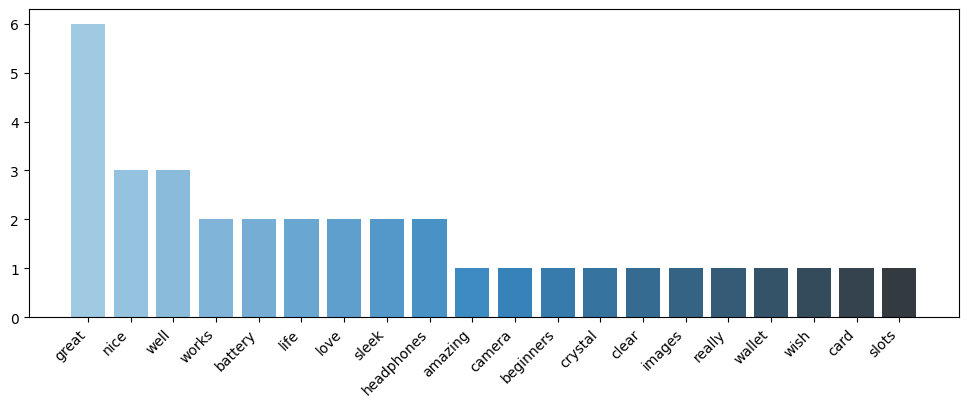

In [5]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

stop_words = set(stopwords.words('english'))

def tokenize_filter(text:str)->list:
    token = word_tokenize(text)
    token = [i for i in token if i.isalpha()]
    token = [i for i in token if i not in stop_words]
    token = [i for i in token if len(i)>2]
    return token
df['token'] = df['clean_text'].apply(tokenize_filter)

all_tokens = [tokens for i in df['token'] for tokens in i]
freq_dict = FreqDist(all_tokens)
top_words = freq_dict.most_common(20)

word, count = zip(*top_words)

tagged = nltk.pos_tag(df["token"][0])

print(f'Total Tokens Count: {len(all_tokens)}')
print(f'Top word: {top_words}')

plt.figure(figsize=(12,4))
bars = plt.bar(word,count,color=sns.color_palette("Blues_d", 20))
plt.xticks(rotation=45, ha='right', fontsize=10)

Sentimental Analysis


In [6]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vader_analysis(text:str) ->dict:
    score = vader.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        label='Positive'
    elif compound <= -0.05:
        label='Negative'
    else:
        label='Netural'
    return {
        'vader_compound' :compound,
        'vader_label': label,
        'vader_pos' : score['pos'],
        'vader_neu' : score['neu'],
        'vader_neg' : score['neg'],
    }

def text_analysis(text:str)->dict:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol >= 0.5:
        label = 'Positive'
    elif pol <= -0.5:
        label = 'Negative'
    else:
        label = 'Netural'
    return {
        'tb_pol' :pol,
        'tb_subj' : subj,
        'tb_label': label,
    }

df.head()
vader_results = df['clean_text'].apply(vader_analysis).apply(pd.Series)
textblob_result = df['clean_text'].apply(text_analysis).apply(pd.Series)

print("Running sentiment analysis...")

df = pd.concat([df,vader_results,textblob_result],axis=1)
df.tail()


Running sentiment analysis...


,Product,Rating,userId,Review,clean_text,proper_noun,ticker,token,vader_compound,vader_label,vader_pos,vader_neu,vader_neg,tb_pol,tb_subj,tb_label
15,Unknown horizon,4,1,Kettle is sleek and boils water fast.,kettle is sleek and boils water fast.,[],[],"[kettle, sleek, boils, water, fast]",0.0000,Netural,0.000,1.000,0.0,0.20,0.600,Netural
16,Light tops,5,2,"Headphones are top-notch, worth every penny.",headphones are top-notch worth every penny.,[],[],"[headphones, worth, every, penny]",0.2263,Positive,0.275,0.725,0.0,0.65,0.550,Positive
17,Khakhi jeans,3,3,"Mascara is okay, but clumps a bit.",mascara is okay but clumps a bit.,[],[],"[mascara, okay, clumps, bit]",0.1154,Positive,0.195,0.805,0.0,0.50,0.500,Positive
18,Black full sleeve,4,4,"Wall art looks great, but frames feel cheap.",wall art looks great but frames feel cheap.,[],[],"[wall, art, looks, great, frames, feel, cheap]",0.3716,Positive,0.267,0.733,0.0,0.60,0.725,Positive
19,Formal for Men,5,5,Yoga mat is comfortable and non-slip.,yoga mat is comfortable and non-slip.,[],[],"[yoga, mat, comfortable]",0.5106,Positive,0.398,0.602,0.0,0.40,0.800,Netural


Final_Analysis              Neutral  Positive
Product                                      
Black Jacket                      1         0
Black full sleeve                 0         1
Black t-shirt for women           1         0
Black top with jeans              0         1
Blue jins                         0         1
Clothes with bag                  1         0
Compact fashion t-shirt           0         1
Formal for Men                    1         0
Gouwn with Red velvet             0         1
Jacket with wollen hat            0         1
Jamdani Saree                     0         1
Jean's stylish Jacket             1         0
Khakhi jeans                      0         1
Light tops                        0         1
Long sleeve Jacket                0         1
Pink beauty                       1         0
Skirts with full setup            1         0
Stylish jeans in lightblue        0         1
Unknown horizon                   1         0
Yellow Hoody                      

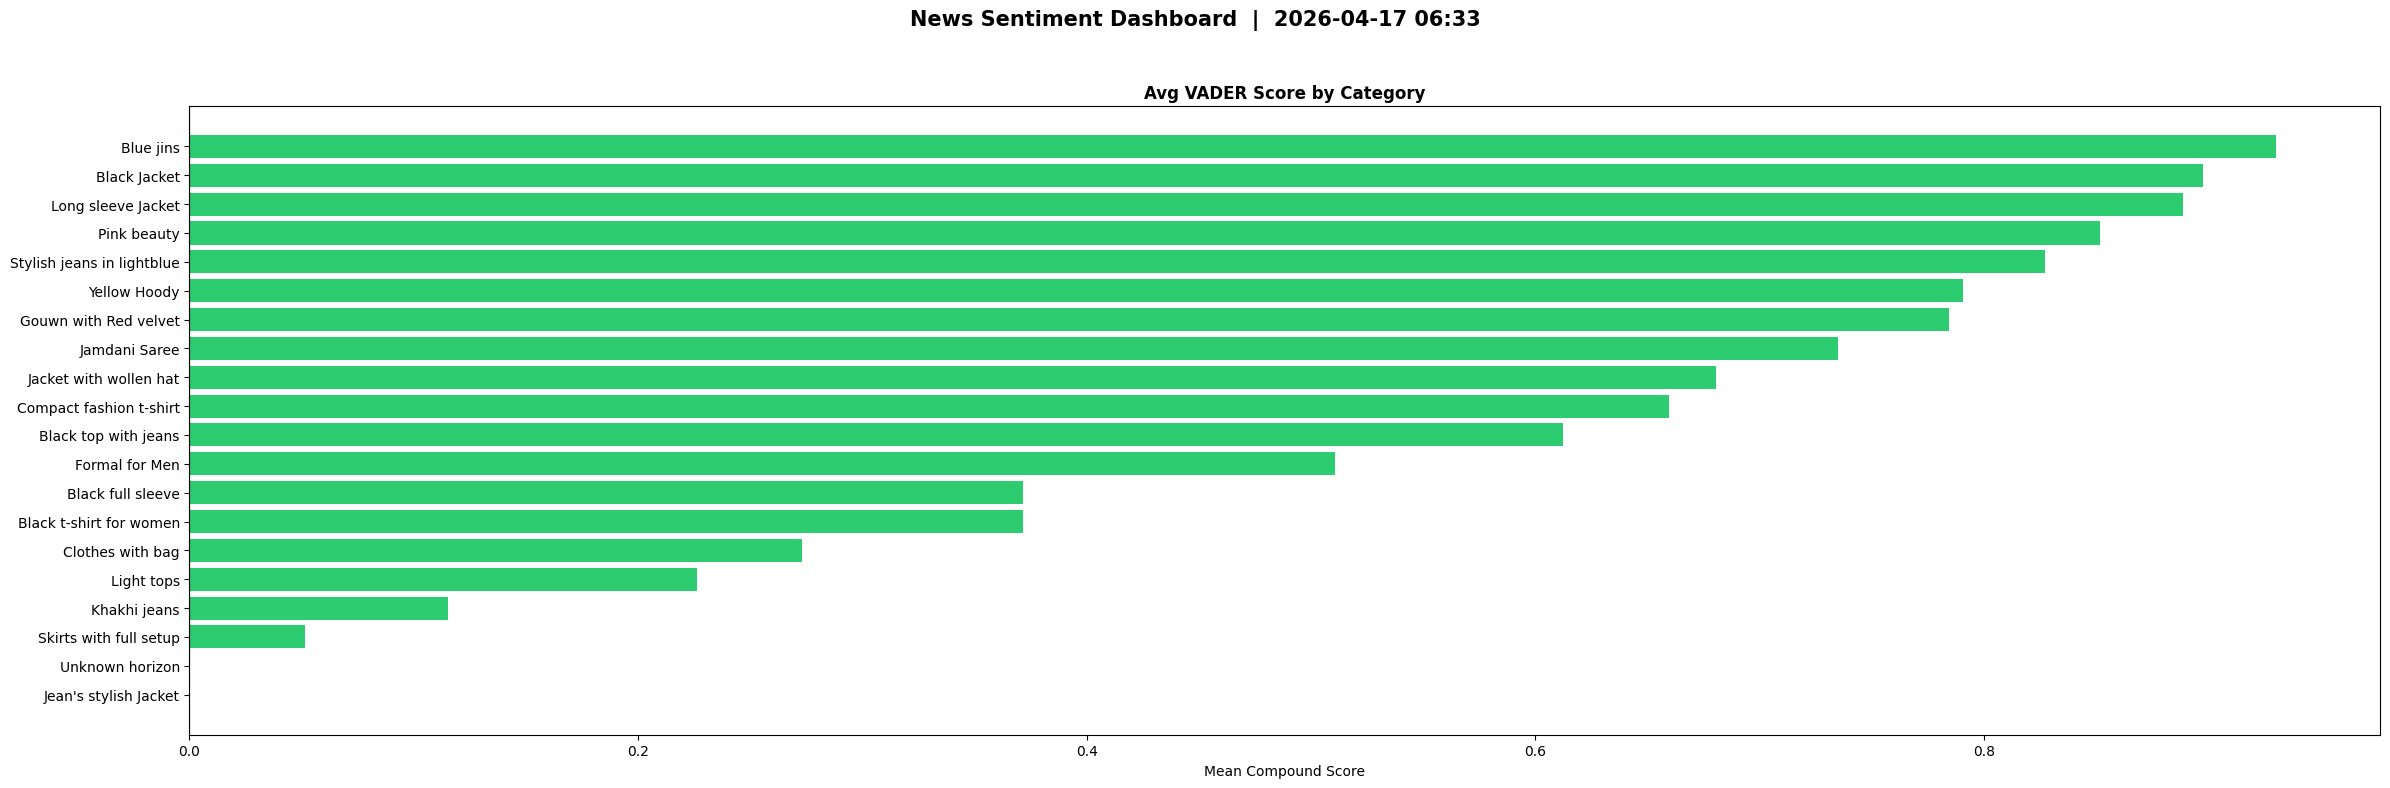

In [7]:
def consolidate_result(row):
    if row['vader_label'] == row['tb_label']:return row['vader_label']
    if row["vader_label"] == "Neutral": return row["tb_label"]
    if row["tb_label"]    == "Neutral": return row["vader_label"]
    return "Neutral"

df['Final_Analysis'] = df.apply(consolidate_result, axis=1)

final_statement = df.groupby(['Product','Final_Analysis']).size().unstack(fill_value=0)
final_statement['Neutral'] = final_statement.get('Neutral', 0) + final_statement.get('Netural', 0)
final_statement.drop(columns=['Netural'], inplace=True)
print(final_statement)


from datetime import datetime

fig, axes = plt.subplots(figsize=(24, 8))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             fontsize=15, fontweight='bold')
cat_avg = df.groupby('Product')['vader_compound'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes.barh(cat_avg.index, cat_avg.values, color=colors)
axes.axvline(0, color='black', linewidth=0.8)
axes.set_title("Avg VADER Score by Category", fontweight='bold')
axes.set_xlabel("Mean Compound Score")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()